## <font color='cornflowerblue'> Dependencies

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import yfinance as yf
import vartools as vt

import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.linear_model import LinearRegression

np.random.seed(42)
plt.rcParams['figure.facecolor'] = 'lightgray'

## <font color='cornflowerblue'> Data and Metrics

In [2]:
# BABA, MSFT, NVDA, PG, V, WM, GLD, GOOGL, AAPL, AMZN, ANET. ASML, AVGO, CRM, DIS, LLY. MKC, RL, JPM

tickers = ['NVDA','AMZN','AVGO','PG','V','RL','GLD']

benchmark = 'SPY'
start_date = '2021-01-01'
end_date = '2025-12-31'

price = yf.download(tickers, start=start_date, end=end_date, progress=False)['Close'][tickers]

benchmark_data = yf.download(benchmark, start=start_date, end=end_date, progress=False)['Close']

rt = price.pct_change().dropna()
rt_benchmark = benchmark_data.pct_change().dropna()

YF.download() has changed argument auto_adjust default to True


In [3]:
pd.set_option('display.float_format', '{:.2%}'.format)

stats_df = pd.DataFrame({
    'Rendimiento Anual': rt.mean() * 252,
    'Volatilidad Anual': rt.std() * np.sqrt(252),
})
stats_df.T

Ticker,NVDA,AMZN,AVGO,PG,V,RL,GLD
Rendimiento Anual,67.11%,13.76%,53.38%,4.90%,13.05%,34.16%,16.97%
Volatilidad Anual,52.24%,35.12%,42.32%,17.28%,22.68%,36.58%,15.62%


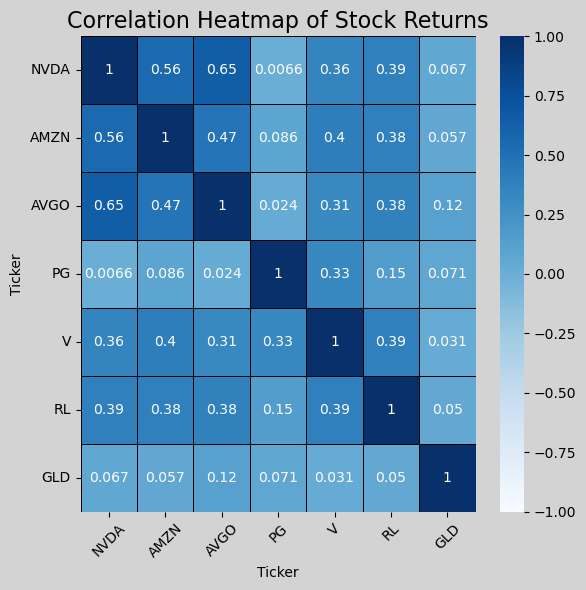

La correlación promedio es: 0.2511


In [4]:
corr = rt.corr()

plt.figure(figsize=(6, 6))
sns.heatmap(corr, 
            annot=True, 
            cmap='Blues', 
            vmin=-1, 
            vmax=1, 
            linewidths=0.5, 
            linecolor='black')

plt.title('Correlation Heatmap of Stock Returns', fontsize=16)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

corr_arr = corr.values
mask = ~np.eye(corr.values.shape[0], dtype=bool)
avg_corr = corr.values[mask].mean()
print(f'La correlación promedio es: {avg_corr:.4f}')

## <font color='cornflowerblue'> Functions

In [5]:
def portfolio_return(returns, weights):
    return np.dot(returns, weights)

def rolling_mean_corr(rt: pd.DataFrame, window: int) -> pd.Series:
    mean_corr = []

    # Compute rolling mean correlation without the diagonal
    for i in range(window, len(rt) + 1):
        corr = rt.iloc[i - window:i].corr().values
        mask = ~np.eye(corr.shape[0], dtype=bool)
        mean_corr.append(corr[mask].mean())

    return pd.Series(mean_corr, index=rt.index[window - 1:])

def var(returns):
    return np.percentile(returns, 1)

def cvar(returns):
    var = np.percentile(returns, 1)
    return returns[returns < var].mean()

def get_metrics(history: pd.DataFrame, rf: float, months: int, benchmark_data: pd.DataFrame):
    # Ajustar longitud del benchmark al periodo de la simulación
    n_days = round(len(benchmark_data) / round(len(benchmark_data) / 252 / (months / 12)), 0) 
    filtered_benchmark_data = benchmark_data.iloc[int(n_days):, :]

    # Calcular rendimientos diarios
    daily_rets = history.pct_change().dropna()
    benchmark_rets = filtered_benchmark_data.pct_change().dropna()

    # Calcular Beta
    X = benchmark_rets.values.reshape(-1, 1)
    y = daily_rets
    betas = [LinearRegression().fit(X, y.values[:, i]).coef_[0] for i in range(y.shape[1])]

    rend_prom = daily_rets.mean()*252
    std__ = daily_rets.std()*np.sqrt(252)
    RS = (rend_prom-rf)/std__
    downside = daily_rets[daily_rets < 0].fillna(0).std()*np.sqrt(252)
    upside = daily_rets[daily_rets > 0].fillna(0).std()*np.sqrt(252)
    omega = upside/downside
    sortino = (rend_prom-rf)/downside

    benchmark_ret = benchmark_rets.mean().iloc[0] * 252
    beta_series = pd.Series(betas, index=daily_rets.columns)
    alpha = rend_prom - (rf + beta_series * (benchmark_ret - rf))

    metrics = pd.DataFrame([rend_prom, std__, RS, downside, upside, omega, sortino],
                           index=['Rend', 'Vol', 'Sharpe', 'Downside', 'Upside', 'Omega', 'Sortino'])
    
    metrics.loc['Beta'] = betas
    metrics.loc['Alpha'] = alpha

    return metrics
    
def get_benchmark_metrics(rt_benchmark_test: pd.DataFrame, rf: float):
    # Cálculo de rendimeinto, volatilidad, Sharpe y Sortino del benchmark
    benchmark_ret = rt_benchmark_test.mean() * 252
    benchmark_vol = rt_benchmark_test.std() * np.sqrt(252)
    benchmark_sharpe = (benchmark_ret - rf) / benchmark_vol

    # Cálculo de el ratio Sortino
    benchmark_down_risk = np.minimum(rt_benchmark_test, 0).std() * np.sqrt(252)
    benchmark_sortino = (benchmark_ret - rf) / benchmark_down_risk

    # Cálculo de el Omega ratio
    benchmark_upside_risk = np.maximum(rt_benchmark_test, 0).std() * np.sqrt(252)
    benchmark_omega = benchmark_upside_risk / benchmark_down_risk

    pd.reset_option('display.float_format')
    summary = pd.DataFrame({
        'Rend': benchmark_ret,
        'Vol': benchmark_vol,
        'Sharpe': benchmark_sharpe,
        'Downside': benchmark_down_risk,
        'Upside': benchmark_upside_risk,
        'Omega': benchmark_omega,
        'Sortino': benchmark_sortino,
        'Alpha': 0,
        'Beta': 1
    })

    summary.set_index(pd.Index(['Benchmark']), inplace=True)
    
    return summary.T

## <font color='cornflowerblue'> Backtest

In [6]:
pd.reset_option('display.float_format')

rf = 0.0375
pv = 1_000_000.0

# Ajustar longitud del benchmark al periodo de la simulación
months = 3
n_days = round(len(benchmark_data) / round(len(benchmark_data) / 252 / (months / 12)), 0) 
benchmark_test = benchmark_data.iloc[int(n_days):, :]
rt_benchmark_test = benchmark_test.pct_change().fillna(0)

history = vt.DynamicBacktesting(price, benchmark_data, capital=1_000_000, rf=rf, months=months, alpha=0.95).simulation()
history_rets = history.pct_change().dropna()

## <font color='cornflowerblue'> Portfolio Evolution

In [7]:
# Benchmark Cumulative Returns
cumulative_benchmark_returns = (1 + rt_benchmark_test).cumprod().squeeze()
cumulative_money_df = pd.DataFrame()
cumulative_money_df['Benchmark'] = pv * cumulative_benchmark_returns.values

# Rolling Metrics
rolling_corr = rolling_mean_corr(rt, window=60)
rolling_std_portfolios = history_rets.rolling(window=60).std().dropna() * np.sqrt(252)
rolling_std_benchmark = rt_benchmark_test.rolling(window=60).std().dropna() * np.sqrt(252)

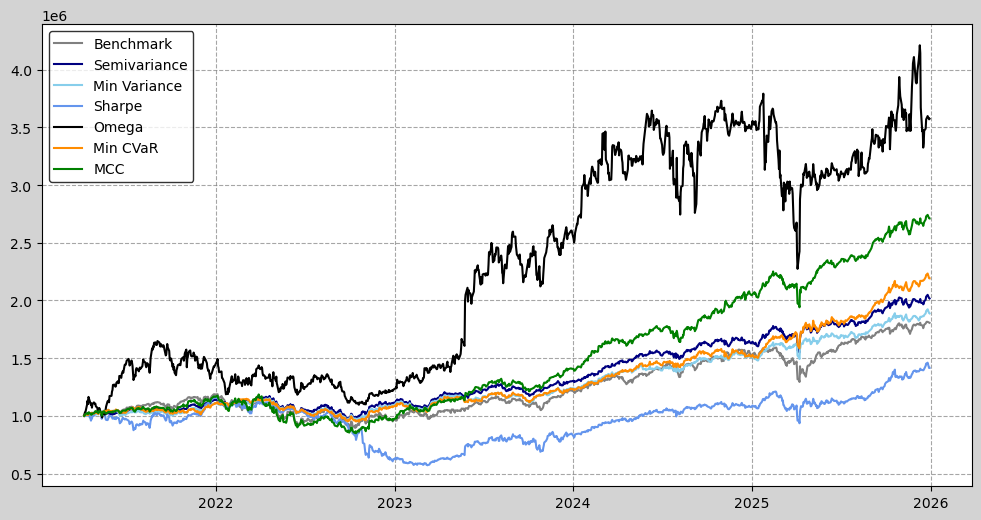

The final value of the Benchmark is 1,806,280.87
The final value of the Min Variance portfolio is 1,888,264.70
The final value of the Sharpe portfolio is 1,415,627.28
The final value of the Semivariance portfolio is 2,017,486.81
The final value of the Omega portfolio is 3,575,247.41
The final value of the Min CVaR portfolio is 2,192,094.26
The final value of the MCC portfolio is 2,711,109.95


In [8]:
STRATEGY_COLORS = {
    'Semivariance': 'navy',
    'Min Variance': 'skyblue',
    'Sharpe': 'cornflowerblue',
    'Omega': 'black',
    'Min CVaR': 'darkorange',
    'MCC': 'green',
}
                                
plt.figure(figsize=(12, 6))
plt.plot(rt_benchmark_test.index, cumulative_money_df['Benchmark'], label='Benchmark', c='gray')
for strategy, color in STRATEGY_COLORS.items():
    plt.plot(rt_benchmark_test.index, history[strategy], label=strategy, c=color)
plt.legend(frameon=True, facecolor='white', edgecolor='black', loc='upper left')                                                                          
plt.grid(True, linestyle='--', color='gray', alpha=0.7)
plt.show()             

print(f'The final value of the Benchmark is {cumulative_money_df["Benchmark"].iloc[-1]:,.2f}')
for i in history.columns:
    print(f'The final value of the {i} portfolio is {history[i].iloc[-1]:,.2f}')

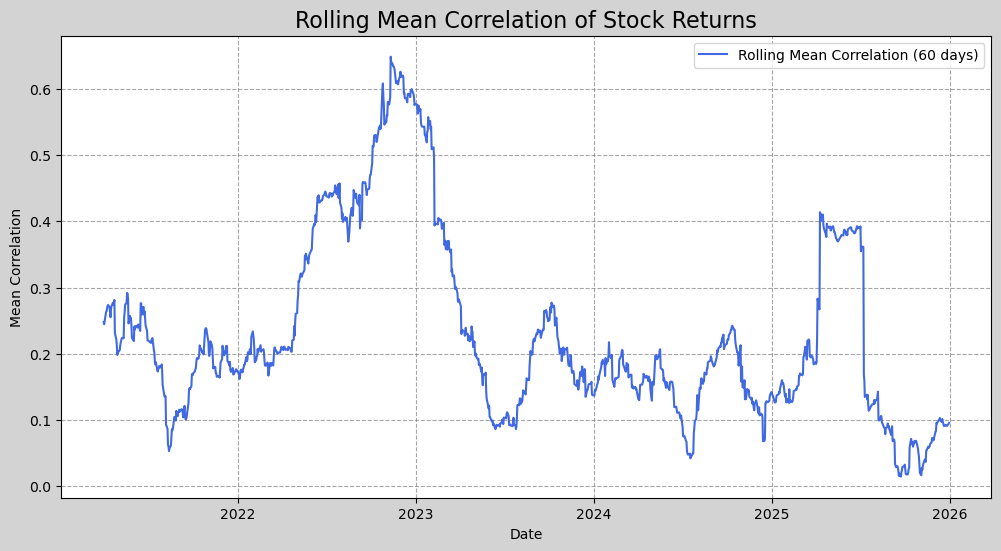

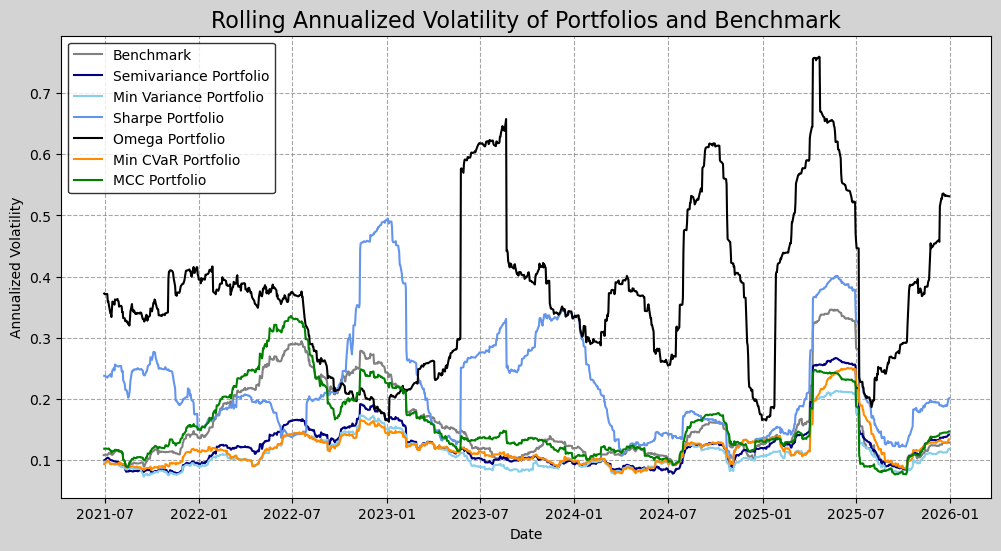

In [9]:
plt.figure(figsize=(12, 6))
plt.plot(rolling_corr.index, rolling_corr.values, color='royalblue', label='Rolling Mean Correlation (60 days)')
plt.title('Rolling Mean Correlation of Stock Returns', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Mean Correlation')
plt.legend()
plt.grid(True, linestyle='--', color='gray', alpha=0.7)
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(rolling_std_benchmark.index, rolling_std_benchmark, label='Benchmark', c='gray')
plt.plot(rolling_std_portfolios.index, rolling_std_portfolios['Semivariance'], label='Semivariance Portfolio', c='navy')
plt.plot(rolling_std_portfolios.index, rolling_std_portfolios['Min Variance'], label='Min Variance Portfolio', c='skyblue')
plt.plot(rolling_std_portfolios.index, rolling_std_portfolios['Sharpe'], label='Sharpe Portfolio', c='cornflowerblue')
plt.plot(rolling_std_portfolios.index, rolling_std_portfolios['Omega'], label='Omega Portfolio', c='black')
plt.plot(rolling_std_portfolios.index, rolling_std_portfolios['Min CVaR'], label='Min CVaR Portfolio', c='darkorange')
plt.plot(rolling_std_portfolios.index, rolling_std_portfolios['MCC'], label='MCC Portfolio', c='green')

plt.title('Rolling Annualized Volatility of Portfolios and Benchmark', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Annualized Volatility')
plt.legend(frameon=True, facecolor='white', edgecolor='black', loc='upper left')
plt.grid(True, linestyle='--', color='gray', alpha=0.7)
plt.show()

## <font color='cornflowerblue'> Performance Metrics

In [10]:
benchmark_metrics = get_benchmark_metrics(rt_benchmark_test, rf)
portfolio_metrics = get_metrics(history, rf, months, benchmark_data)

all_metrics = pd.concat([benchmark_metrics, portfolio_metrics], axis=1)
display(all_metrics)

lower_is_better = ["Vol", "Downside", "Beta"]

def rowwise_gradient(row):
    if row.name in lower_is_better:
        return pd.Series(row.max() - row, index=row.index)
    return row

styled = all_metrics.copy()
styled = styled.apply(rowwise_gradient, axis=1)

styled.style.background_gradient(cmap="RdYlGn", axis=1)

,Benchmark,Min Variance,Sharpe,Semivariance,Omega,Min CVaR,MCC
Rend,0.139867,0.141303,0.102323,0.156976,0.348820,0.174018,0.225413
Vol,0.171906,0.115454,0.240307,0.129058,0.399255,0.124648,0.168121
Sharpe,0.595482,0.899082,0.269749,0.925759,0.779751,1.095230,1.117725
Downside,0.104495,0.067960,0.145297,0.075415,0.229839,0.072296,0.100836
Upside,0.106589,0.070573,0.151651,0.080343,0.264204,0.077004,0.103357
Omega,1.020042,1.038455,1.043725,1.065341,1.149517,1.065121,1.025004
Sortino,0.979634,1.527407,0.446137,1.584244,1.354509,1.888324,1.863558
Alpha,0.000000,0.066307,-0.010587,0.069104,0.182044,0.100793,0.099730
Beta,1.000000,0.365868,0.735813,0.491509,1.261422,0.348589,0.860457


,Benchmark,Min Variance,Sharpe,Semivariance,Omega,Min CVaR,MCC
Rend,0.139867,0.141303,0.102323,0.156976,0.348820,0.174018,0.225413
Vol,0.227350,0.283801,0.158949,0.270198,0.000000,0.274608,0.231134
Sharpe,0.595482,0.899082,0.269749,0.925759,0.779751,1.095230,1.117725
Downside,0.125345,0.161879,0.084542,0.154424,0.000000,0.157544,0.129004
Upside,0.106589,0.070573,0.151651,0.080343,0.264204,0.077004,0.103357
Omega,1.020042,1.038455,1.043725,1.065341,1.149517,1.065121,1.025004
Sortino,0.979634,1.527407,0.446137,1.584244,1.354509,1.888324,1.863558
Alpha,0.000000,0.066307,-0.010587,0.069104,0.182044,0.100793,0.099730
Beta,0.261422,0.895554,0.525609,0.769913,0.000000,0.912833,0.400964


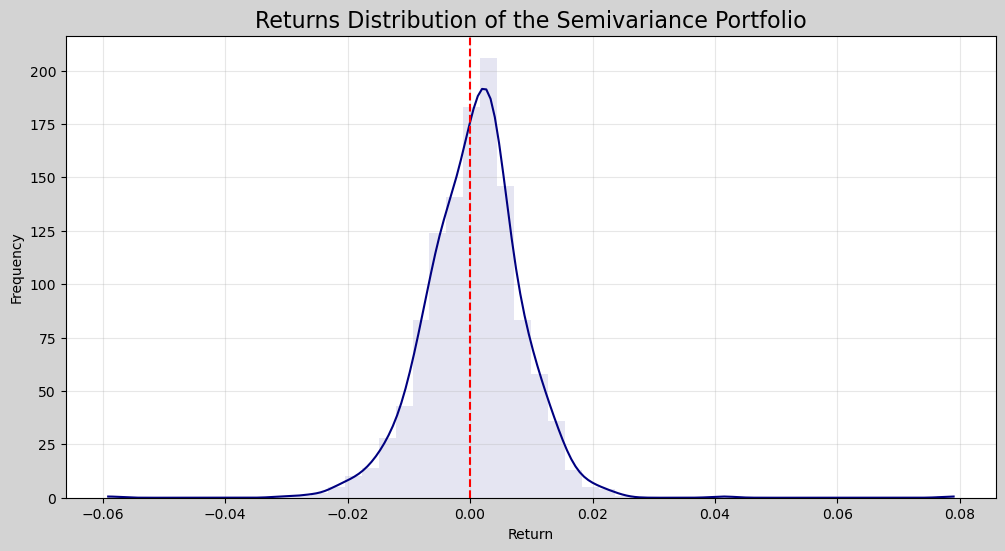

In [11]:
portfolio_winner = 'Semivariance'

plt.figure(figsize=(12, 6))
sns.histplot(history_rets[portfolio_winner], color='navy', alpha=0.1, kde=True, bins=50, edgecolor=None)
plt.title(f'Returns Distribution of the {portfolio_winner} Portfolio', fontsize=16)
plt.xlabel('Return')
plt.ylabel('Frequency')
plt.axvline(x=0, color='red', linestyle='--', label='Zero')
plt.grid(alpha=0.3)
plt.show()

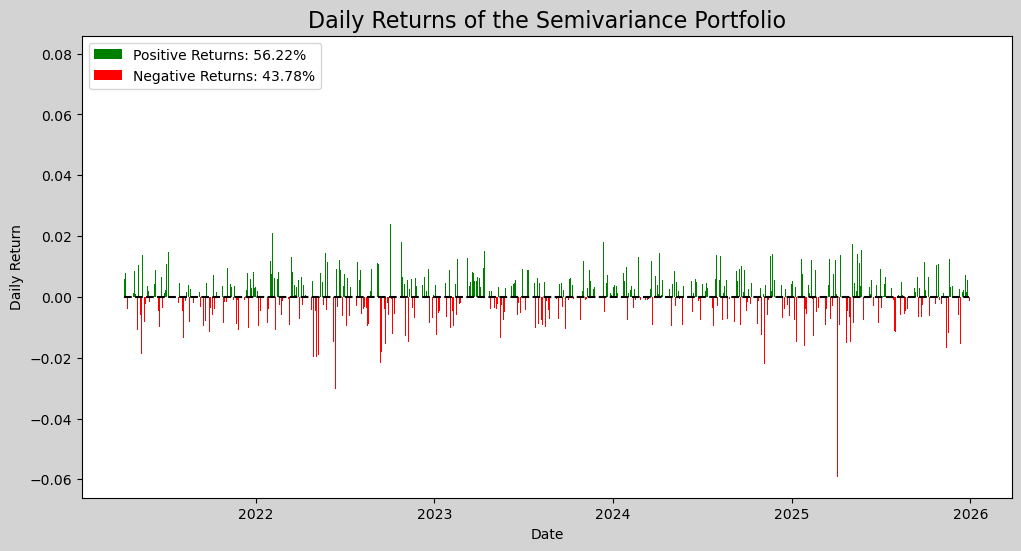

In [12]:
rets = pd.Series(history_rets[portfolio_winner])

positive = len(history_rets[portfolio_winner][history_rets[portfolio_winner] > 0])
negative = len(history_rets[portfolio_winner][history_rets[portfolio_winner] < 0])
positive_percentage = positive / (positive + negative)
negative_percentage = negative / (positive + negative)

plt.figure(figsize=(12, 6))
plt.bar(rets.index[rets > 0], rets[rets > 0], color='green', label=f'Positive Returns: {positive_percentage:.2%}')
plt.bar(rets.index[rets < 0], rets[rets < 0], color='red', label=f'Negative Returns: {negative_percentage:.2%}')
plt.title(f'Daily Returns of the {portfolio_winner} Portfolio', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Daily Return')
plt.hlines(0, rets.index[0], rets.index[-1], colors='black', linestyles='dashed')
plt.legend()
plt.show()

## <font color='cornflowerblue'> VaR and C-VaR

In [13]:
print(f'VaR with 99% confidence at one day for the {portfolio_winner} portfolio is {var(history_rets[portfolio_winner]):.2%}')
print(f'ES with 99% confidence at one day for the {portfolio_winner} portfolio is {cvar(history_rets[portfolio_winner]):.2%}')

VaR with 99% confidence at one day for the Semivariance portfolio is -1.97%
ES with 99% confidence at one day for the Semivariance portfolio is -2.61%
